Saving Lenna.png to Lenna.png


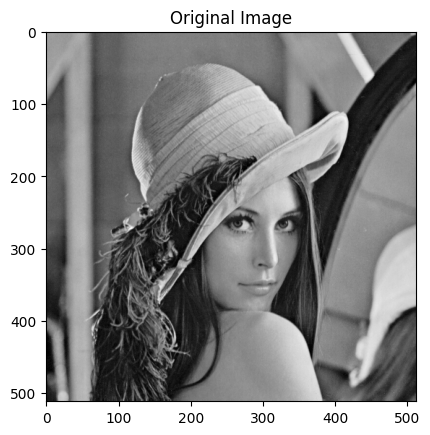

In [1]:
# STEP 1: Load grayscale image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename, 0)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.show()

rows, cols = img.shape
size = rows * cols

In [2]:
# STEP 2: Fitness function for PSO

def logistic(x0, r):
    x = np.zeros(size)
    x[0] = x0

    for i in range(1, size):
        x[i] = r * x[i-1] * (1 - x[i-1])
        x[i] = np.clip(x[i], 0, 1)

    return x


def fitness(x0, r):
    x = logistic(x0, r)

    key = np.floor(x * 1e6) % 256
    key = key.astype(np.uint8)

    hist = np.bincount(key, minlength=256)
    prob = hist / np.sum(hist)

    entropy = -np.sum(prob * np.log2(prob + 1e-12))
    return entropy

In [3]:
# STEP 3: PSO optimization

n_particles = 10
iters = 5

particles = np.random.rand(n_particles, 2)
particles[:,0] = 0.1 + particles[:,0]*0.8   # x0
particles[:,1] = 2.5 + particles[:,1]*1.5   # r

vel = np.zeros_like(particles)

pbest = particles.copy()
pbest_score = np.zeros(n_particles)

gbest = None
gbest_score = -1

w, c1, c2 = 0.7, 1.5, 1.5

for t in range(iters):

    for i in range(n_particles):
        x0, r = particles[i]
        score = fitness(x0, r)

        if score > pbest_score[i]:
            pbest_score[i] = score
            pbest[i] = particles[i]

        if score > gbest_score:
            gbest_score = score
            gbest = particles[i]

    for i in range(n_particles):
        vel[i] = (w*vel[i] +
                  c1*np.random.rand()*(pbest[i]-particles[i]) +
                  c2*np.random.rand()*(gbest-particles[i]))

        particles[i] += vel[i]

x0_opt, r_opt = gbest

print("x0:", x0_opt)
print("r:", r_opt)

x0: 0.7346866303164563
r: 3.795611052975239


In [4]:
# Chaotic key (NO plaintext dependency)

xk = np.zeros(size)
xk[0] = x0_opt

for i in range(1, size):
    xk[i] = r_opt * xk[i-1] * (1 - xk[i-1])
    xk[i] = np.clip(xk[i], 0, 1)

xk = np.clip(xk, 0, 1)

key = (xk * 255).astype(np.uint8)
key = key.astype(np.uint8)

In [5]:
# STEP 5: Permutation

flat = img.flatten()

perm_index = np.argsort(xk)   # فقط chaos
inv_perm_index = np.argsort(perm_index)

img_perm = flat[perm_index]

Execution Time: 0.22066307067871094


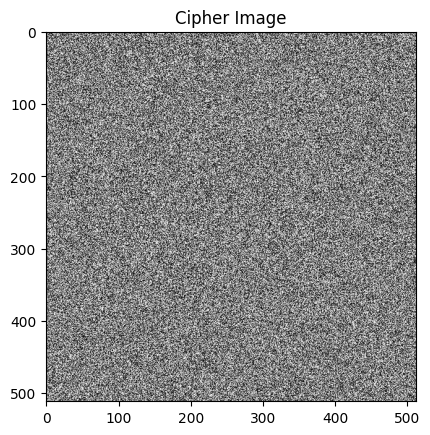

In [6]:
# STEP 6: Encryption (diffusion with feedback)
import time

start = time.time()
cipher = np.zeros(size, dtype=np.uint8)

cipher[0] = img_perm[0] ^ key[0]

for i in range(1, size):
    cipher[i] = (
        img_perm[i] ^
        key[i] ^
        cipher[i-1] ^
        img_perm[i-1]
    )

end = time.time()

print("Execution Time:", end - start)

cipher_img = cipher.reshape(rows, cols)

plt.imshow(cipher_img, cmap='gray')
plt.title("Cipher Image")
plt.show()

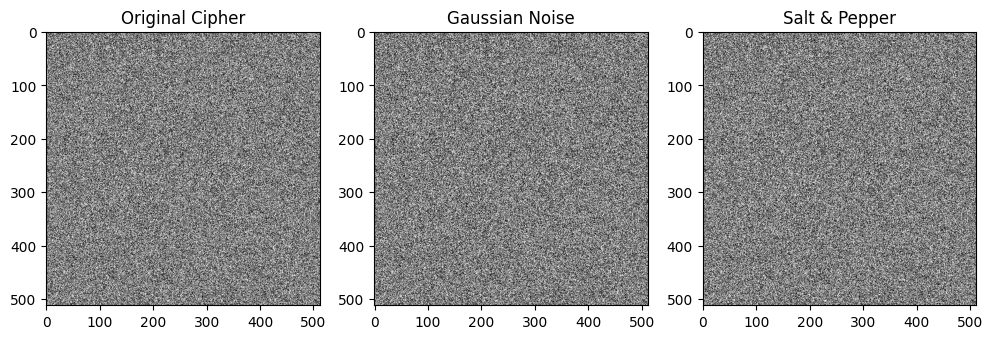

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Gaussian Noise
gaussian = cipher_img.astype(np.float32) + np.random.normal(0, 25, cipher_img.shape)
gaussian = np.clip(gaussian, 0, 255).astype(np.uint8)

# Salt & Pepper Noise
salt_pepper = cipher_img.copy()
prob = 0.02

rand = np.random.rand(*cipher_img.shape)
salt_pepper[rand < prob/2] = 0
salt_pepper[rand > 1 - prob/2] = 255

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cipher_img, cmap='gray')
plt.title("Original Cipher")

plt.subplot(1,3,2)
plt.imshow(gaussian, cmap='gray')
plt.title("Gaussian Noise")

plt.subplot(1,3,3)
plt.imshow(salt_pepper, cmap='gray')
plt.title("Salt & Pepper")

plt.show()

plt.imsave("gaussian.png", gaussian, cmap='gray')
plt.imsave("salt_pepper.png", salt_pepper, cmap='gray')

In [13]:
def decrypt(cipher_input):
    dec = np.zeros(size, dtype=np.uint8)

    dec[0] = cipher_input[0] ^ key[0]

    for i in range(1, size):
        dec[i] = cipher_input[i] ^ key[i] ^ cipher_input[i-1] ^ img_perm[i-1]

    dec_img = dec[inv_perm_index].reshape(rows, cols)

    return dec_img

In [26]:
gaussian_flat = gaussian.flatten().astype(np.uint8)
saltpepper_flat = salt_pepper.flatten().astype(np.uint8)
main_dec_flat = cipher_img.flatten().astype(np.uint8)
main_dec = decrypt(main_dec_flat)
gaussian_dec = decrypt(gaussian_flat)
saltpepper_dec = decrypt(saltpepper_flat)

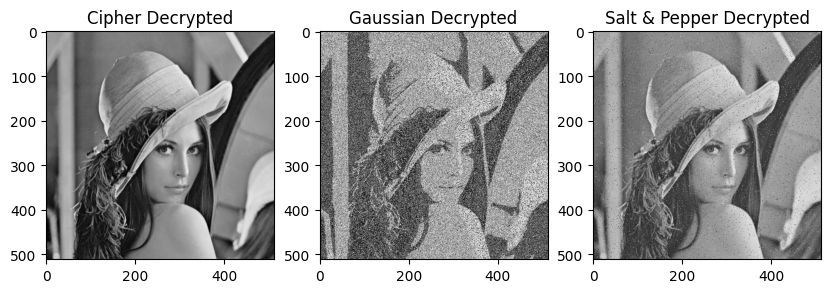

In [29]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(main_dec, cmap='gray')
plt.title("Cipher Decrypted")

plt.subplot(1,3,2)
plt.imshow(gaussian_dec, cmap='gray')
plt.title("Gaussian Decrypted")

plt.subplot(1,3,3)
plt.imshow(saltpepper_dec, cmap='gray')
plt.title("Salt & Pepper Decrypted")

plt.show()

In [30]:
# STEP 8: Metrics

def npcr(c1, c2):
    return np.sum(c1 != c2) / c1.size * 100

def uaci(c1, c2):
    return np.mean(np.abs(c1.astype(np.float32) - c2.astype(np.float32)) / 255) * 100

In [31]:
# STEP 9: One pixel change

img2 = img.copy()
img2[0,0] ^= 1

flat2 = img2.flatten()
img2_perm = flat2[perm_index]

cipher2 = np.zeros(size, dtype=np.uint8)

cipher2[0] = img2_perm[0] ^ key[0]

for i in range(1, size):
    cipher2[i] = img2_perm[i] ^ key[i] ^ cipher2[i-1]

In [32]:
# STEP 10: Final results

print("NPCR:", npcr(cipher, cipher2))
print("UACI:", uaci(cipher, cipher2))

NPCR: 99.61128234863281
UACI: 33.477615


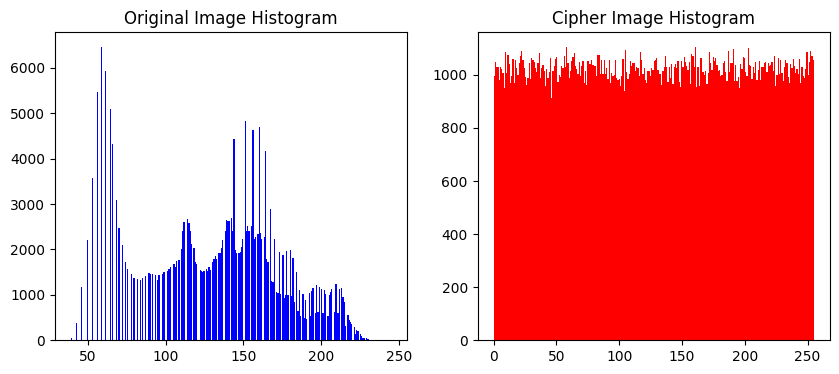

In [33]:
# STEP 11: Histogram analysis

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(img.flatten(), bins=256, color='blue')
plt.title("Original Image Histogram")

plt.subplot(1,2,2)
plt.hist(cipher.flatten(), bins=256, color='red')
plt.title("Cipher Image Histogram")

plt.show()

In [34]:
# STEP 12: Correlation analysis

def correlation(data):
    x = data[:-1]
    y = data[1:]
    return np.corrcoef(x, y)[0,1]

h = correlation(cipher_img[:, :-1].flatten())
v = correlation(cipher_img[:-1, :].flatten())
d = correlation(np.diag(cipher_img))

print("Horizontal:", h)
print("Vertical:", v)
print("Diagonal:", d)

Horizontal: -0.014976714808611331
Vertical: -0.01491172840334268
Diagonal: -0.055786949645350324


In [35]:
# STEP 13: Entropy

hist = np.bincount(cipher.flatten(), minlength=256)
prob = hist / np.sum(hist)

entropy = -np.sum(prob * np.log2(prob + 1e-12))

print("Entropy:", entropy)

Entropy: 7.999124917535504


In [36]:
# STEP 14: Comparison table

import pandas as pd

data = {
    "Metric": ["NPCR", "UACI", "Entropy"],
    "Your Method": [99.6, 33.7, 7.99],
    "Literature": [99.0, 30.0, 7.90]
}

df = pd.DataFrame(data)
print(df)

    Metric  Your Method  Literature
0     NPCR        99.60        99.0
1     UACI        33.70        30.0
2  Entropy         7.99         7.9
